In [1]:
#ultralytics
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.93 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 43.6/235.7 GB disk)


In [2]:
#google drive
from google.colab import drive
drive.mount('/content/drive')

#for UTF8 error when downloading ultralytics results from colab
import locale
locale.getpreferredencoding = lambda: "UTF-8"

import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
model = ultralytics.YOLO('yolov8m')

100%|██████████| 49.7M/49.7M [00:00<00:00, 229MB/s]


In [ ]:
model.train(data='', epochs=150, imgsz=512, batch=64)

Ultralytics 8.3.93 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/drive/MyDrive/Stave_Project/data_for_training/yolo_format/staves_localizer/stavesImg50.yaml, epochs=150, time=None, patience=100, batch=64, imgsz=512, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, sav

100%|██████████| 755k/755k [00:00<00:00, 27.3MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 183MB/s]


AMP: checks passed ✅


...

                   all          9          9      0.994          1      0.995      0.971



150 epochs completed in 0.190 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train/weights/best.pt, 52.0MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.93 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 10.36it/s]


                   all          9          9      0.989          1      0.995      0.981
Speed: 0.1ms preprocess, 4.7ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b959b057e90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
results = model.val(data="")
print(results)

Ultralytics 8.3.93 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning /content/drive/.shortcut-targets-by-id/1B5568bIq8F-Y9_NKFOOLNg1afBLZMJC2/Stave_Project/data_for_training/yolo_format/staves_localizer/stavesImgs50/labels/val.cache... 9 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9/9 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:02<00:00,  2.29s/it]


                   all          9          9      0.989          1      0.995      0.981
Speed: 0.1ms preprocess, 24.9ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs/detect/train2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b967b9010d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.03

In [3]:
def visualize_results(test_results, result_show_limit=20):
  # Collect plotted images from results
  grid_imgs = []
  for i, result in enumerate(test_results):
      if i >= result_show_limit:
          break
      # result.plot() returns an image (NumPy array) with predictions overlaid
      img = result.plot()
      grid_imgs.append(img)

  # Determine grid dimensions (e.g., 4 columns; adjust rows accordingly)
  cols = 4
  rows = int(np.ceil(len(grid_imgs) / cols))

  # Create a figure to display the grid
  fig, axs = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

  for idx, ax in enumerate(axs.flat):
      if idx < len(grid_imgs):
          # Convert BGR (if using OpenCV) to RGB if needed
          # img = cv2.cvtColor(grid_imgs[idx], cv2.COLOR_BGR2RGB)
          ax.imshow(grid_imgs[idx])
          ax.set_title(f"Result {idx+1}")
      ax.axis('off')

#conf thresholding at 80
def crop_and_save_images_from_results(test_results=None, output_folder=None):
  conf_thresh = 0.8
  if test_results:
    for a_result in test_results:
      box_cords = a_result.boxes.xyxy.tolist()
      conf_score = a_result.boxes.conf.tolist()
      img_path = a_result.path

      img_name = img_path.split('/')[-1].split(".")[0]
      img_save_path = os.path.join(output_folder, img_name)
      print(img_path)
      img_obj = cv2.imread(img_path)
      if img_obj is not None:
        for i, (a_conf, a_cord_set) in enumerate(zip(conf_score, box_cords)):
          print(a_conf, a_cord_set)
          if a_conf > conf_thresh:
            if a_cord_set is not None:
                x1, y1, x2, y2 = a_cord_set
                img_cropped_obj = img_obj[int(y1):int(y2), int(x1):int(x2)]
                cv2.imwrite(f"{img_save_path}_{i}.jpeg", img_cropped_obj)

In [4]:
weights_path = ""
input_folder = ""
output_folder = ""

In [ ]:
model = ultralytics.YOLO(weights_path)
test_results = model.predict(input_folder, imgsz=512, batch=1, half=True)

In [ ]:
crop_and_save_images_from_results(test_results, output_folder)

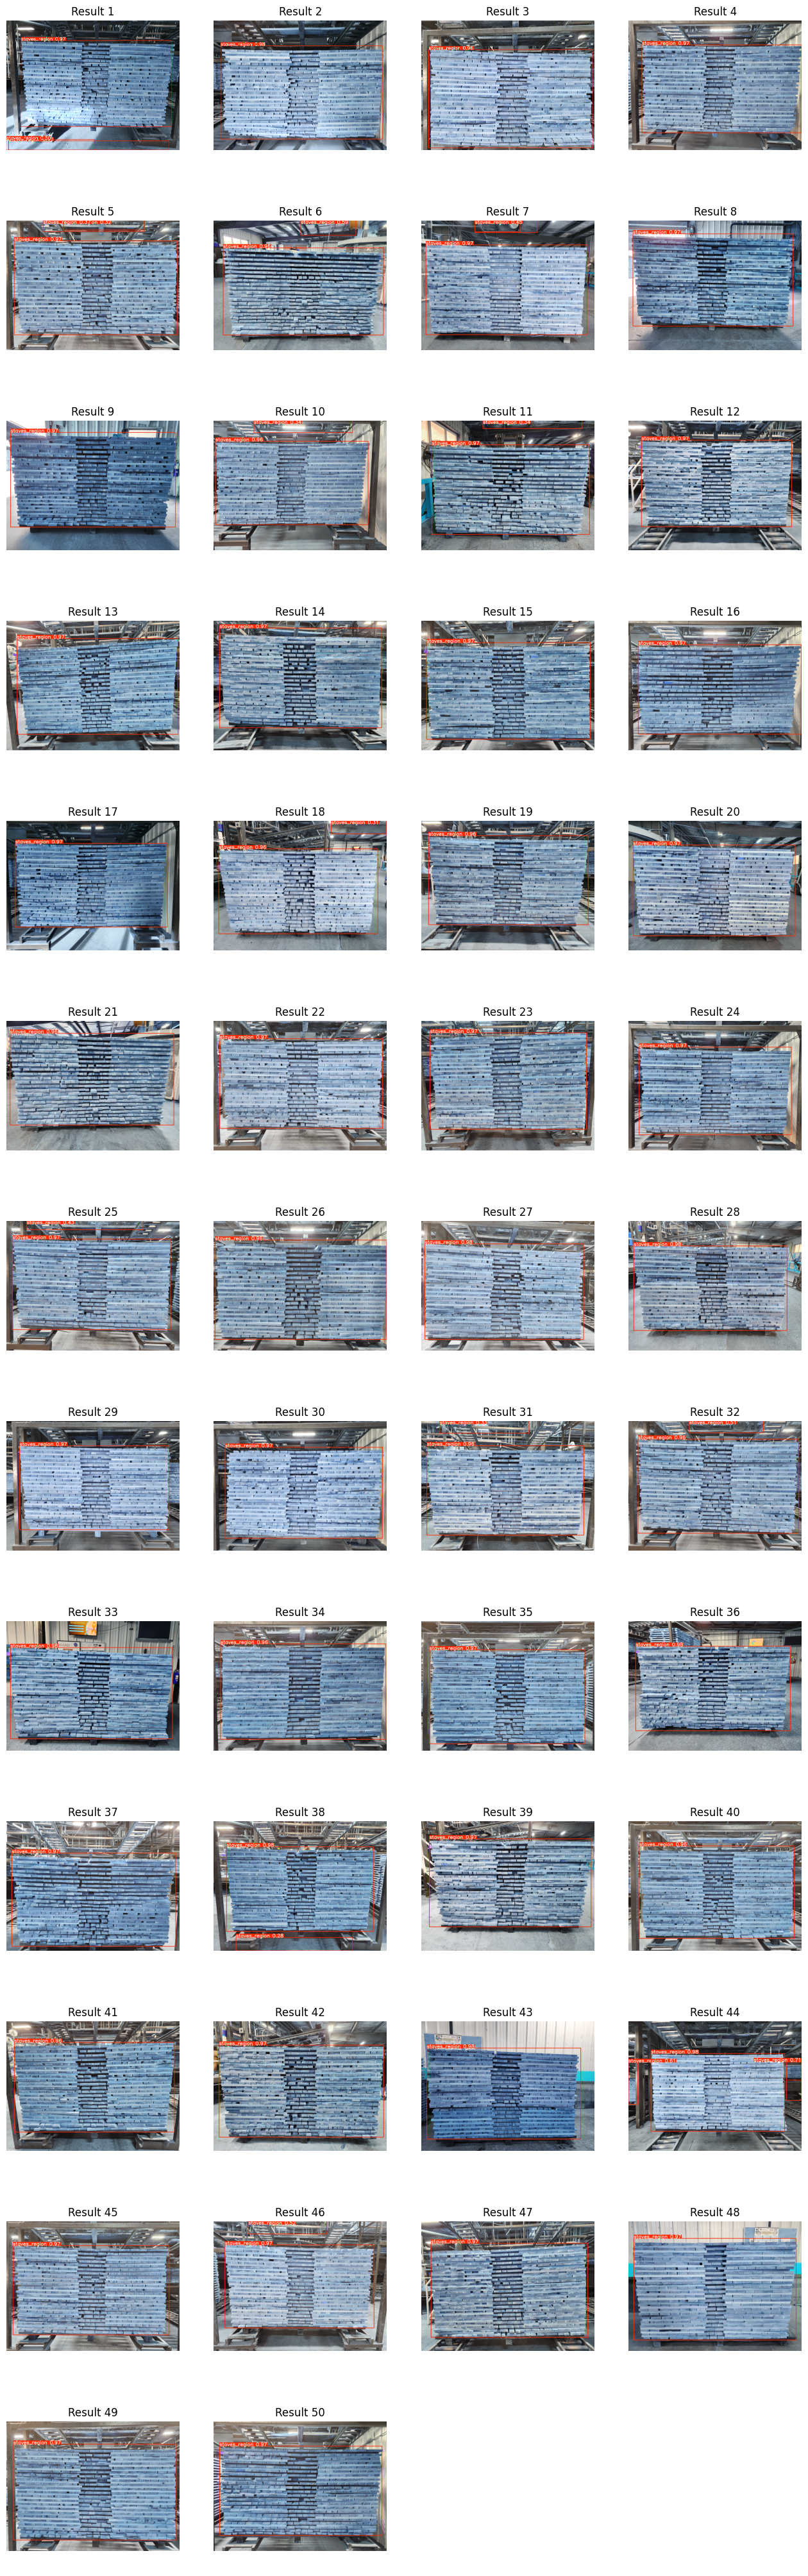

In [25]:
visualize_results(test_results, result_show_limit=50)